# 04a — Modélisation : Random Forest (FD001)

**Objectif** : entraîner un Random Forest sur les features tabulaires (statistiques glissantes), valider ses performances, et sauvegarder ses prédictions sur le jeu de test pour comparaison ultérieure.

In [1]:
# --- Imports et configuration ---
from pathlib import Path
import sys

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

PROJECT_ROOT = Path.cwd().resolve().parents[1]
sys.path.append(str(PROJECT_ROOT))

SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

SUBSET = "FD001"

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / "ml"
MODELS_DIR = PROJECT_ROOT / "models" / "ml"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR = PROJECT_ROOT / "reports" / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures" / "modelisation"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
features_train = pd.read_parquet(PROCESSED_DIR / f"train_{SUBSET}_features.parquet")
features_test = pd.read_parquet(PROCESSED_DIR / f"test_{SUBSET}_features.parquet")

colonnes_features = [c for c in features_train.columns if c not in ["unit_number", "time_in_cycles", "op_setting_1", "op_setting_2", "RUL"]]

print(f"{len(colonnes_features)} features")
print(f"train : {features_train.shape}, test : {features_test.shape}")

60 features
train : (20631, 65), test : (100, 65)


## 1. Séparation train / validation

On découpe le train en deux, mais par moteur entier (pas par ligne) : sans ça, deux cycles voisins d'un même moteur, très proches l'un de l'autre, se retrouveraient l'un en apprentissage et l'autre en validation — la validation serait artificiellement trop optimiste.

In [3]:
separateur = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
idx_train, idx_val = next(separateur.split(features_train, groups=features_train["unit_number"]))

X_train, y_train = features_train.iloc[idx_train][colonnes_features], features_train.iloc[idx_train]["RUL"]
X_val, y_val = features_train.iloc[idx_val][colonnes_features], features_train.iloc[idx_val]["RUL"]

moteurs_train = features_train.iloc[idx_train]["unit_number"].nunique()
moteurs_val = features_train.iloc[idx_val]["unit_number"].nunique()

print(f"Apprentissage : {X_train.shape[0]} lignes, {moteurs_train} moteurs")
print(f"Validation    : {X_val.shape[0]} lignes, {moteurs_val} moteurs")

Apprentissage : 16561 lignes, 80 moteurs
Validation    : 4070 lignes, 20 moteurs


**Interprétation** : le découpage se fait par moteur entier (80 moteurs pour l'apprentissage, 20 pour la validation), jamais par ligne — deux cycles consécutifs du même moteur ne se retrouvent donc jamais séparés entre les deux ensembles.

## 2. Entraînement

In [4]:
modele = RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1)
modele.fit(X_train, y_train)

print("Entrainement termine.")

Entrainement termine.


## 3. Évaluation sur la validation

In [5]:
predictions_val = modele.predict(X_val)

rmse_val = root_mean_squared_error(y_val, predictions_val)
mae_val = mean_absolute_error(y_val, predictions_val)

print(f"RMSE (validation) : {rmse_val:.2f} cycles")
print(f"MAE (validation)  : {mae_val:.2f} cycles")

RMSE (validation) : 17.34 cycles
MAE (validation)  : 12.54 cycles


**Interprétation** : le modèle se trompe en moyenne de 12,5 cycles (MAE) sur la RUL, avec un RMSE de 17,3 cycles. Les capteurs avaient d'abord été normalisés avec un MinMaxScaler calculé par moteur, mais cette approche faussait les résultats sur le test : elle réduisait la performance réelle du modèle tout en donnant l'illusion d'une bonne validation. On est passé à un MinMaxScaler unique, ajusté une seule fois sur tout le train — le chiffre obtenu ici est plus élevé qu'avant, mais il reflète la vraie performance du modèle.

## 4. Importance des features

Quels capteurs (et quelles statistiques) le modèle utilise-t-il le plus pour prédire la RUL ?

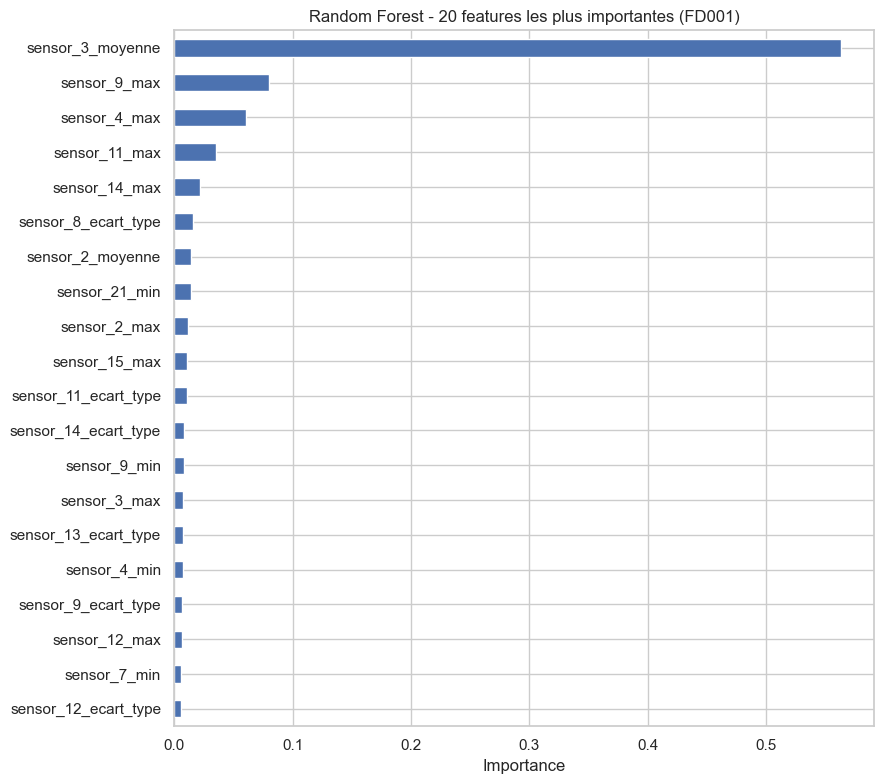

In [6]:
importances = pd.Series(modele.feature_importances_, index=colonnes_features).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 8))
importances.head(20).sort_values().plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_xlabel("Importance")
ax.set_title(f"Random Forest - 20 features les plus importantes ({SUBSET})")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "rf_importance_features.png")
plt.show()

**Interprétation** : sensor_3_moyenne domine désormais l'importance (plus de 55 %), suivi de sensor_9_max et sensor_4_max. Le classement a changé par rapport à l'ancienne normalisation par moteur — logique, puisque l'échelle des valeurs elle-même a changé.

## 5. Prédictions sur le test et sauvegarde

In [7]:
X_test = features_test[colonnes_features]
y_test = features_test["RUL"]
predictions_test = modele.predict(X_test)

resultats_test = pd.DataFrame({
    "unit_number": features_test["unit_number"],
    "RUL_reelle": y_test,
    "RUL_predite": predictions_test,
})
resultats_test.to_csv(RESULTS_DIR / f"predictions_random_forest_{SUBSET}.csv", index=False)

joblib.dump(modele, MODELS_DIR / f"random_forest_{SUBSET}.joblib")

print("Predictions et modele sauvegardes.")
resultats_test.head()

Predictions et modele sauvegardes.


,unit_number,RUL_reelle,RUL_predite
0,1,112,123.310
1,2,98,96.520
2,3,69,57.835
3,4,82,98.275
4,5,91,94.180


## Synthèse

Le Random Forest a été entraîné sur les features tabulaires, validé par groupe de moteurs (pas de fuite entre apprentissage et validation), et ses prédictions sur le test sont sauvegardées dans `reports/results/` pour comparaison avec les autres approches.